In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random
import cv2

import torch

from Generator import generate_image
from Generator import noise_add, noise_mul

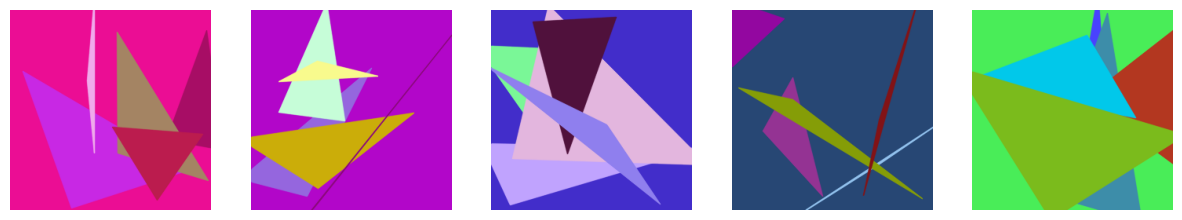

In [2]:
images = [generate_image(256, 256, 5, 0, 0, 0) for _ in range(5)]

fig, ax_table = plt.subplots(1, 5, figsize=(15, 3), facecolor='none')
for i, ax in enumerate(ax_table.ravel()):
    ax.imshow(images[i])
    ax.set_axis_off()

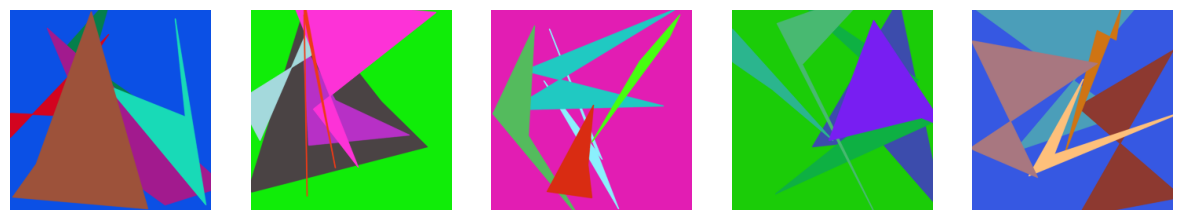

In [3]:
images = [generate_image(256, 256, 0, 5, 0, 0) for _ in range(5)]

fig, ax_table = plt.subplots(1, 5, figsize=(15, 3), facecolor='none')
for i, ax in enumerate(ax_table.ravel()):
    ax.imshow(images[i])
    ax.set_axis_off()

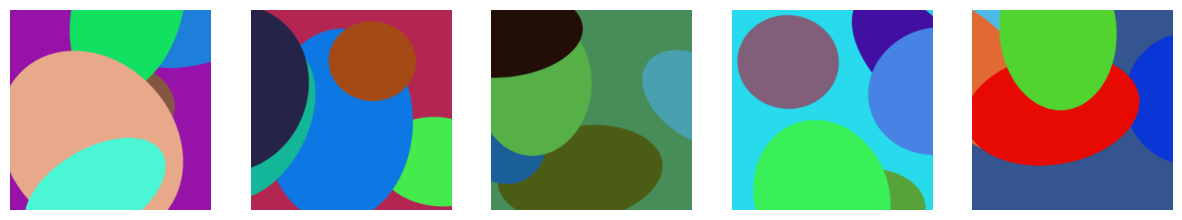

In [4]:
images = [generate_image(256, 256, 0, 0, 5, 0) for _ in range(5)]

fig, ax_table = plt.subplots(1, 5, figsize=(15, 3), facecolor='none')
for i, ax in enumerate(ax_table.ravel()):
    ax.imshow(images[i])
    ax.set_axis_off()

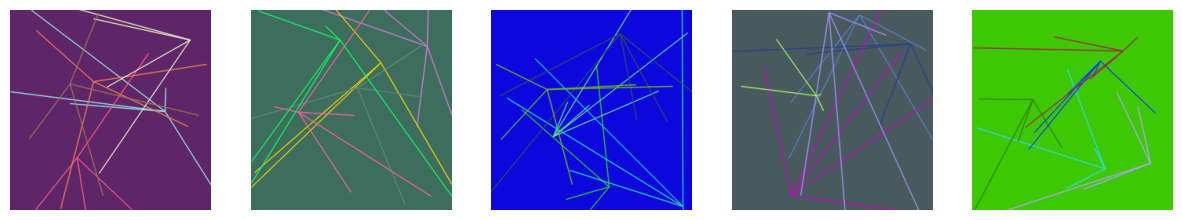

In [5]:
images = [generate_image(256, 256, 0, 0, 0, 5) for _ in range(5)]

fig, ax_table = plt.subplots(1, 5, figsize=(15, 3), facecolor='none')
for i, ax in enumerate(ax_table.ravel()):
    ax.imshow(images[i])
    ax.set_axis_off()

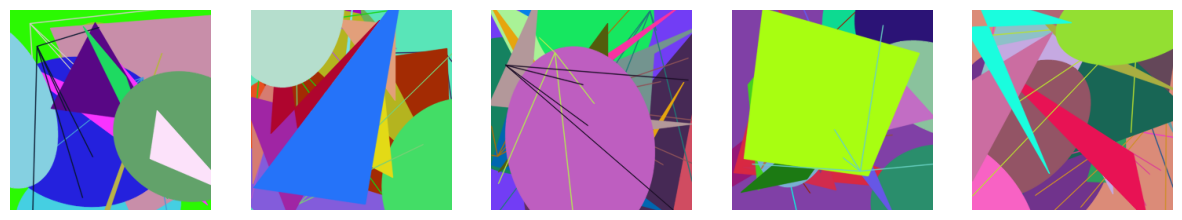

In [6]:
images = [generate_image(256, 256, 5, 5, 5, 5) for _ in range(5)]

fig, ax_table = plt.subplots(1, 5, figsize=(15, 3), facecolor='none')
for i, ax in enumerate(ax_table.ravel()):
    ax.imshow(images[i])
    ax.set_axis_off()


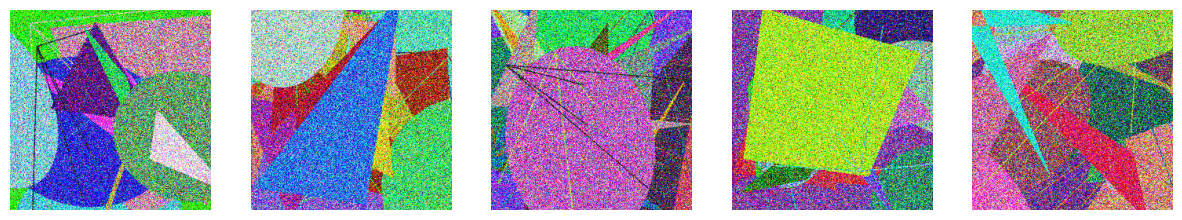

In [7]:
# noisy_images_additive = [noise_add(img, random.uniform(0.1, 0.3)) for img in images]
noisy_images_additive = [noise_add(img, 0.3) for img in images]

fig, ax_table = plt.subplots(1, 5, figsize=(15, 3), facecolor='none')
for i, ax in enumerate(ax_table.ravel()):
    ax.imshow(noisy_images_additive[i])
    ax.set_axis_off()

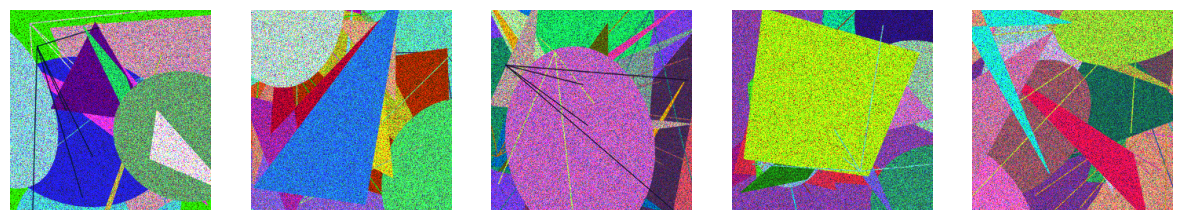

In [8]:
# noisy_images_multiplicative = [noise_mul(img, random.uniform(0.1, 0.3)) for img in images]
noisy_images_multiplicative = [noise_mul(img, 0.3) for img in images]

fig, ax_table = plt.subplots(1, 5, figsize=(15, 3), facecolor='none')
for i, ax in enumerate(ax_table.ravel()):
    ax.imshow(noisy_images_multiplicative[i])
    ax.set_axis_off()
img = generate_image(256, 256, 5, 5, 5, 5)


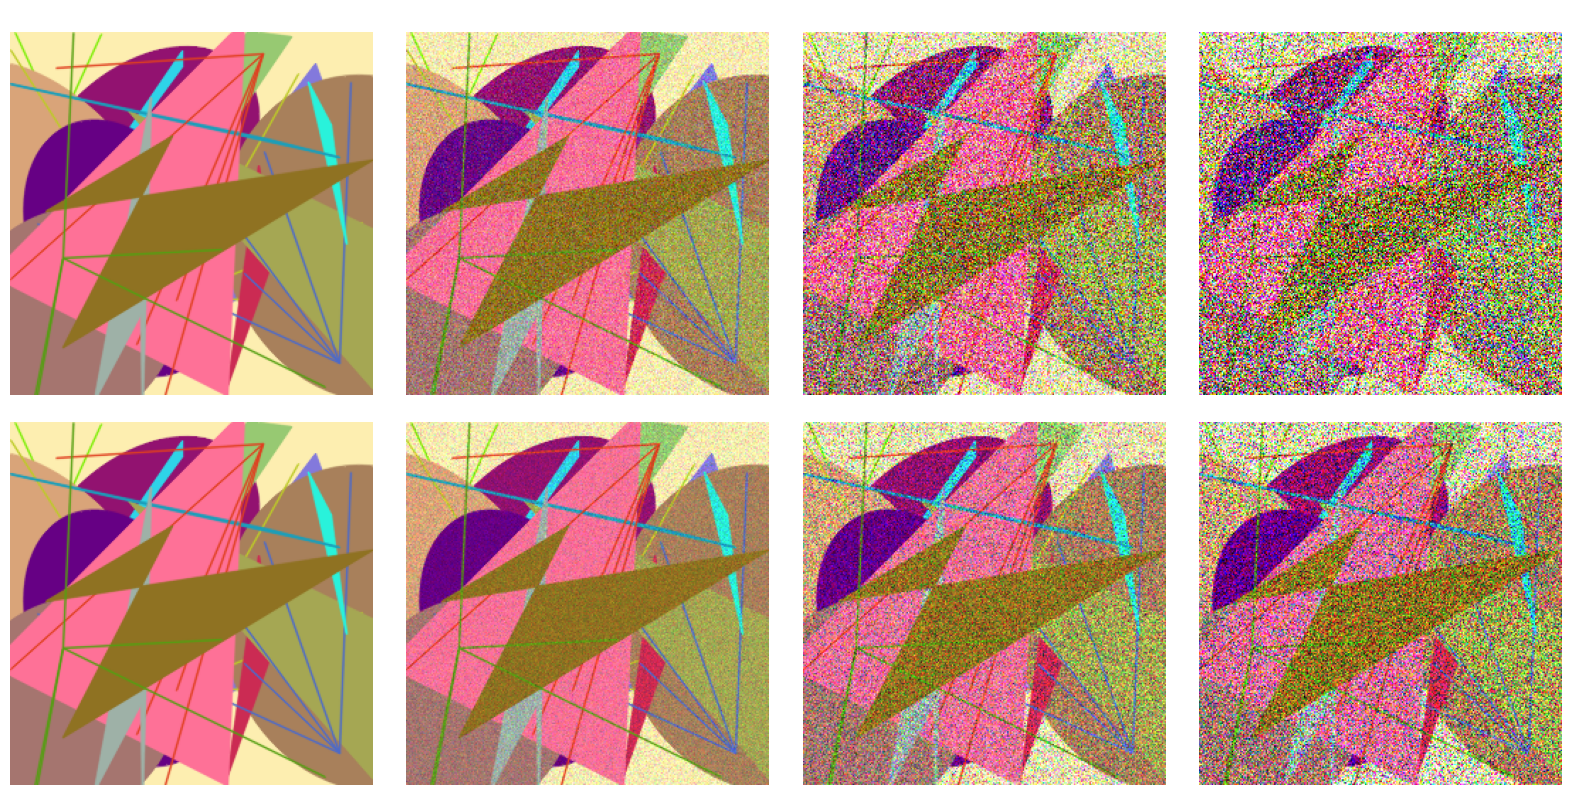

In [9]:
noise_levels = [0.0, 0.1, 0.3, 0.5]
titles = ['No Noise', 'Noise 0.1', 'Noise 0.3', 'Noise 0.5']

fig, axes = plt.subplots(2, 4, figsize=(16, 8), facecolor='none')
for i, level in enumerate(noise_levels):
    if level == 0.0:
        axes[0, i].imshow(img)
    else:
        noisy = noise_add(img, level)
        axes[0, i].imshow(noisy)
    axes[0, i].set_title(f"Additive: {titles[i]}", color="white")
    axes[0, i].set_axis_off()

for i, level in enumerate(noise_levels):
    if level == 0.0:
        axes[1, i].imshow(img)
    else:
        noisy = noise_mul(img, level)
        axes[1, i].imshow(noisy)
    axes[1, i].set_title(f"Multiplicative: {titles[i]}", color="white")
    axes[1, i].set_axis_off()

plt.tight_layout()
plt.show()

In [10]:
from Helper import load_checkpoint_generic
from Model import EdgePreservingDenoiser

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = EdgePreservingDenoiser().to(device)
checkpoint_dir = "checkpoints-noise_mul"
checkpoint = load_checkpoint_generic(checkpoint_dir, device)
if checkpoint:
    model.load_state_dict(checkpoint['model_state_dict'])
    iteration = checkpoint['iteration']
    print(f"Checkpoint loaded at iteration {iteration}.")
else:
    print("No checkpoint found.")


✅ Loaded checkpoint: checkpoints-noise_mul\checkpoint_iteration_900.pth (iteration 900)
Checkpoint loaded at iteration 900.


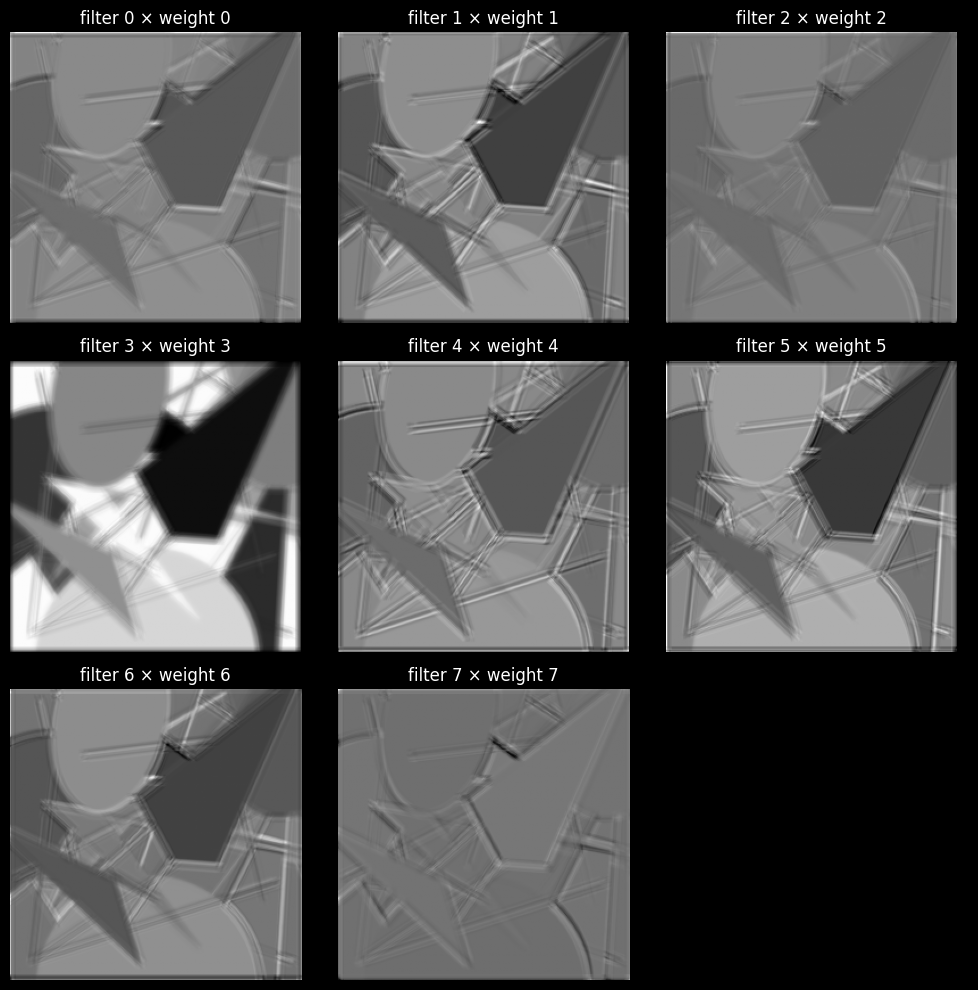

In [11]:
def visualize_filter_weights(model, input_image, device):
    model.eval()
    with torch.no_grad():
        x = torch.tensor(input_image.transpose(2, 0, 1), dtype=torch.float32).unsqueeze(0).to(device) / 255.0
        filtered = model.filter_branch(x)  # (1, 3, 8, H, W)
        weights = model.weight_branch(x)[0]  # (8, H, W)

    R_filtered = filtered[0, 0]

    fig, axes = plt.subplots(3, 3, figsize=(10, 10))
    axes = axes.ravel()
    for i in range(8):
        weighted_response = R_filtered[i].cpu().numpy() * weights[i].cpu().numpy()
        axes[i].imshow(weighted_response, cmap='gray')
        axes[i].set_title(f'filter {i} × weight {i}')
        axes[i].axis('off')
    axes[8].axis('off')
    plt.tight_layout()
    plt.show()


visualize_filter_weights(model, generate_image(256, 256, 5, 5, 5, 5), device)

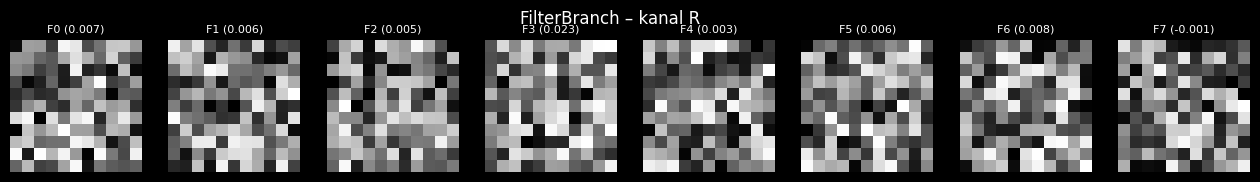

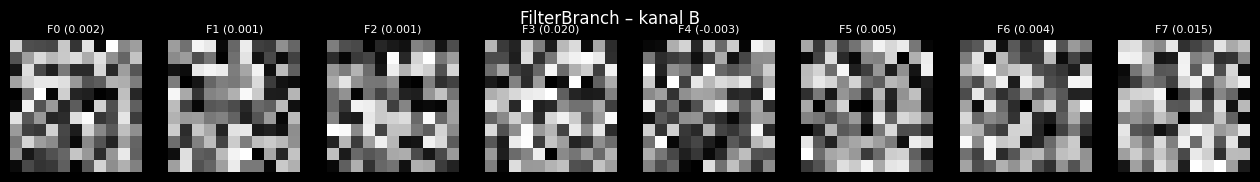

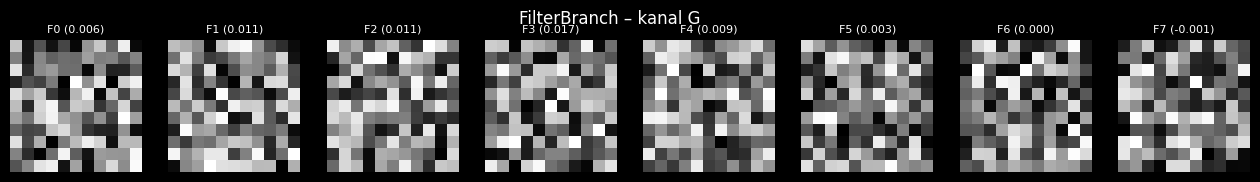

torch.Size([8, 11, 11])


In [12]:
import matplotlib.pyplot as plt


def get_channel_filters(model, channel: str = 'R', show: bool = True):
    fb = model.filter_branch
    if channel == 'R':
        conv = fb.R_conv
    elif channel == 'G':
        conv = fb.G_conv
    elif channel == 'B':
        conv = fb.B_conv
    else:
        raise ValueError("channel mora biti eden izmed: 'R', 'G', 'B'")

    weights = conv.weight.data.cpu().squeeze(1)  # (8, 11, 11)

    if show:
        n_filters = weights.shape[0]
        n_cols = min(8, n_filters)
        n_rows = (n_filters + n_cols - 1) // n_cols

        plt.figure(figsize=(n_cols * 2, n_rows * 2))
        for i in range(n_filters):
            plt.subplot(n_rows, n_cols, i + 1)
            plt.imshow(weights[i], cmap='gray')
            plt.axis('off')
            # Display mean weight value in title
            mean_weight = weights[i].mean().item()
            plt.title(f'F{i} ({mean_weight:.3f})', fontsize=8)
        plt.suptitle(f'FilterBranch – kanal {channel}', color='white')
        plt.show()

    return weights


r_filters = get_channel_filters(model, 'R', show=True)
b_filters = get_channel_filters(model, 'B', show=True)
g_filters = get_channel_filters(model, 'G', show=True)
print(b_filters.shape)

In [13]:
def psnr_torch(img, recon, max_val=1.0, eps=1e-10):
    mse = torch.mean((img - recon) ** 2)
    mse = torch.clamp(mse, min=eps)
    # Fix: Use torch.tensor with same device as mse
    max_val_tensor = torch.tensor(max_val, device=mse.device)
    return 20.0 * torch.log10(max_val_tensor) - 10.0 * torch.log10(mse)


def snr_torch(clean, recon, eps=1e-10):
    signal_power = torch.mean(clean ** 2)
    noise_power = torch.mean((clean - recon) ** 2)
    noise_power = torch.clamp(noise_power, min=eps)
    return 10.0 * torch.log10(signal_power / noise_power)


def nn_test_single(model, img_np, noise_fn, noise_level, device):
    model.eval()
    noisy_np = noise_fn(img_np, noise_level)

    clean_t = torch.tensor(img_np.transpose(2, 0, 1), dtype=torch.float32).unsqueeze(0).to(device) / 255.0
    noisy_t = torch.tensor(noisy_np.transpose(2, 0, 1), dtype=torch.float32).unsqueeze(0).to(device) / 255.0

    with torch.no_grad():
        out_t = model(noisy_t).clamp(0.0, 1.0)

    clean_b = clean_t.squeeze(0).cpu()
    noisy_b = noisy_t.squeeze(0).cpu()
    out_b = out_t.squeeze(0).cpu()

    psnr_noisy = psnr_torch(clean_b, noisy_b, max_val=1.0).item()
    snr_noisy = snr_torch(clean_b, noisy_b).item()
    psnr_denoised = psnr_torch(clean_b, out_b, max_val=1.0).item()
    snr_denoised = snr_torch(clean_b, out_b).item()

    metrics = {
        "psnr_noisy": psnr_noisy,
        "snr_noisy": snr_noisy,
        "psnr_denoised": psnr_denoised,
        "snr_denoised": snr_denoised
    }

    # Fix: Remove redundant .cpu() call
    out_np = (out_b.numpy().transpose(1, 2, 0) * 255.0).round().astype(np.uint8)

    return img_np, noisy_np, out_np, metrics



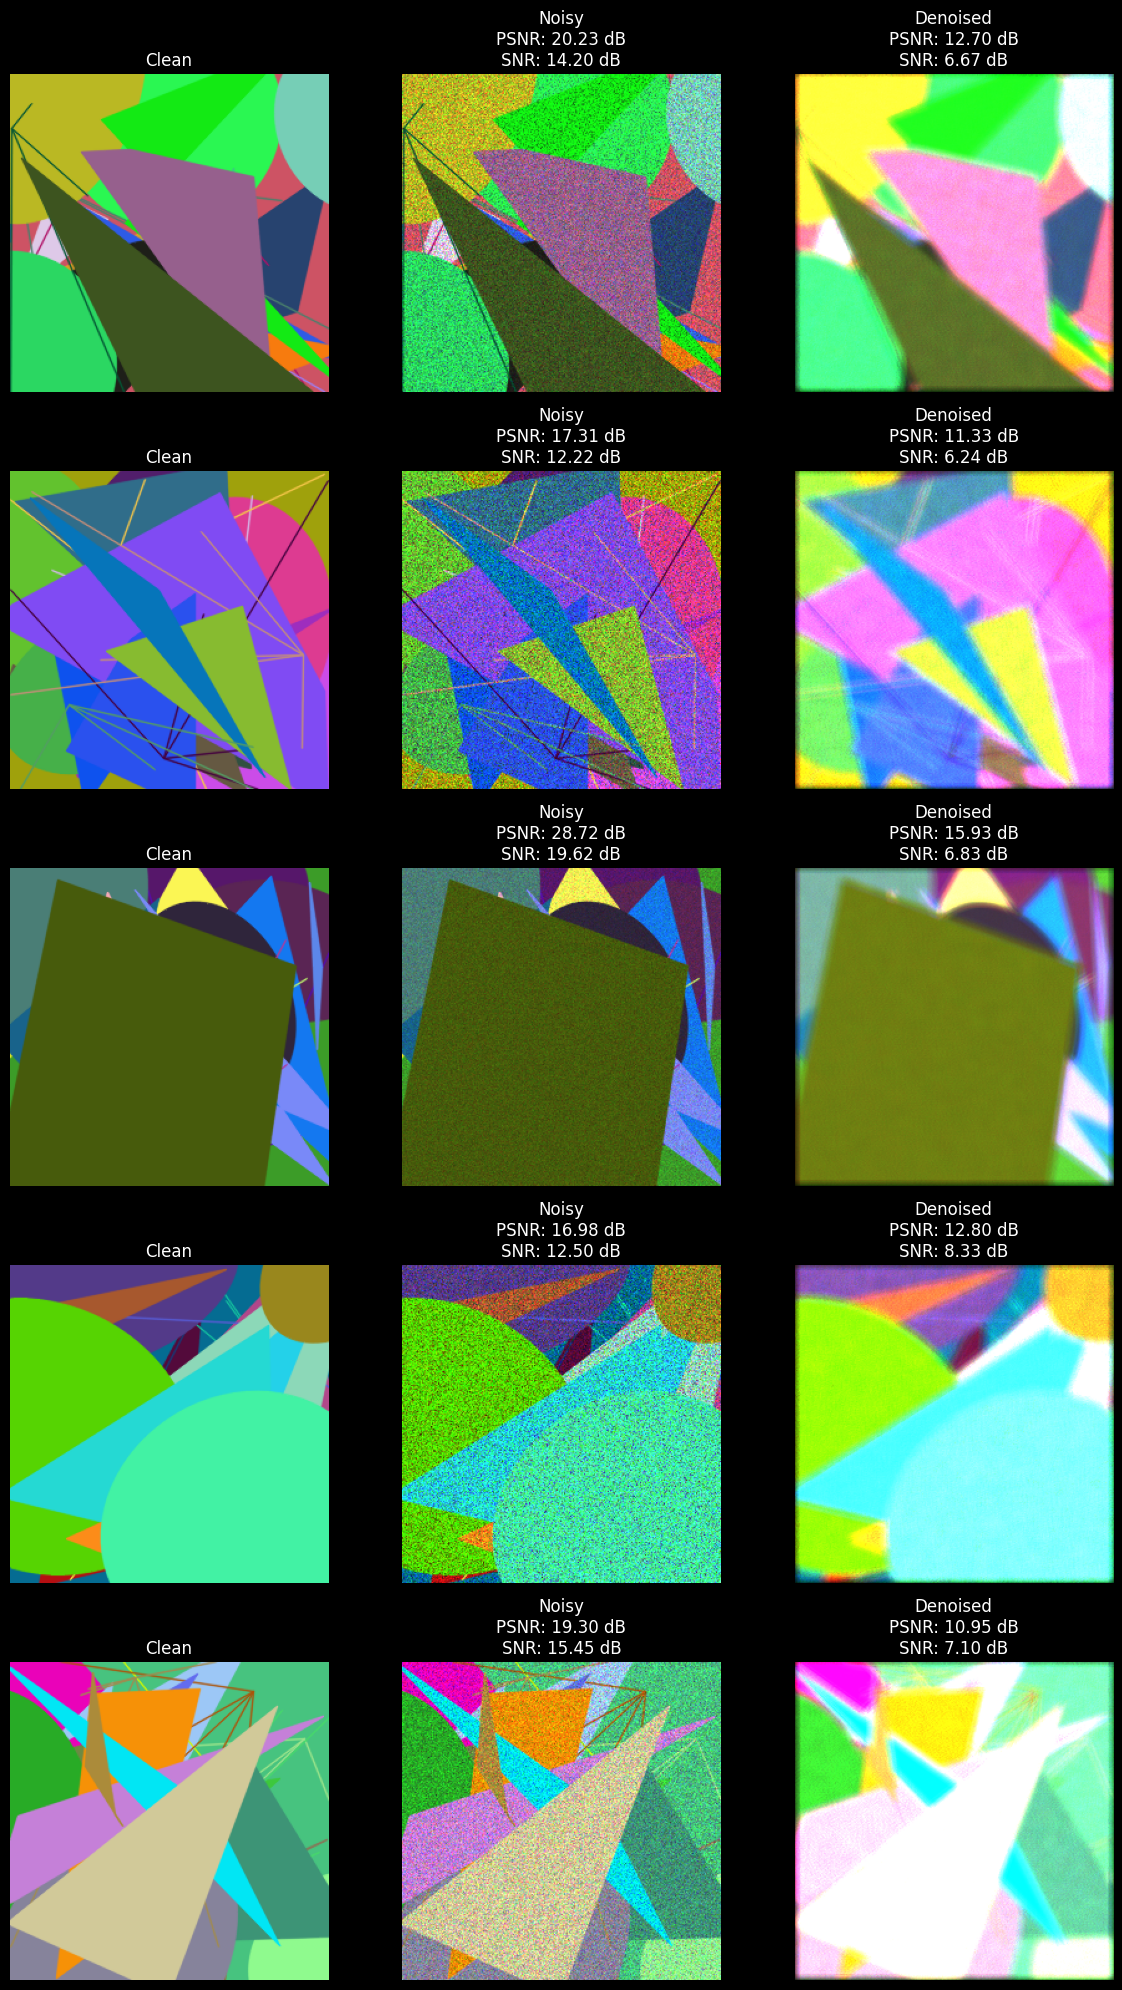


Results over 5 tests:
Average PSNR (noisy):     20.51 dB
Average PSNR (denoised):  12.74 dB
Average SNR  (noisy):     14.80 dB
Average SNR  (denoised):  7.03 dB
PSNR improvement: -7.77 dB
SNR improvement:  -7.77 dB


In [14]:
model.eval()

num_of_tests = 5  # Recommended: Use more than 1 for better testing
noise_fn = noise_mul

# Fix: Handle single test case properly
if num_of_tests == 1:
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes = [axes]  # Make it iterable like 2D array
else:
    fig, axes = plt.subplots(num_of_tests, 3, figsize=(12, 4 * num_of_tests))

psnr_noisy_list = []
psnr_denoised_list = []
snr_noisy_list = []
snr_denoised_list = []

for i in range(num_of_tests):
    img = generate_image(256, 256, 5, 5, 5, 5)
    clean, noisy, denoised, metrics = nn_test_single(model, img, noise_fn, np.random.uniform(0.1, 0.3), device)

    psnr_noisy_list.append(metrics["psnr_noisy"])
    psnr_denoised_list.append(metrics["psnr_denoised"])
    snr_noisy_list.append(metrics["snr_noisy"])
    snr_denoised_list.append(metrics["snr_denoised"])

    ax0, ax1, ax2 = axes[i]

    ax0.imshow(clean)
    ax0.set_title("Clean")
    ax0.axis("off")

    ax1.imshow(noisy)
    ax1.set_title(f"Noisy\nPSNR: {metrics['psnr_noisy']:.2f} dB\nSNR: {metrics['snr_noisy']:.2f} dB")
    ax1.axis("off")

    ax2.imshow(denoised)
    ax2.set_title(f"Denoised\nPSNR: {metrics['psnr_denoised']:.2f} dB\nSNR: {metrics['snr_denoised']:.2f} dB")
    ax2.axis("off")

plt.tight_layout()
plt.show()

print(f"\n{'=' * 50}")
print(f"Results over {num_of_tests} tests:")
print(f"{'=' * 50}")
print(f"Average PSNR (noisy):     {np.mean(psnr_noisy_list):.2f} dB")
print(f"Average PSNR (denoised):  {np.mean(psnr_denoised_list):.2f} dB")
print(f"Average SNR  (noisy):     {np.mean(snr_noisy_list):.2f} dB")
print(f"Average SNR  (denoised):  {np.mean(snr_denoised_list):.2f} dB")
print(f"{'=' * 50}")
print(f"PSNR improvement: {np.mean(psnr_denoised_list) - np.mean(psnr_noisy_list):.2f} dB")
print(f"SNR improvement:  {np.mean(snr_denoised_list) - np.mean(snr_noisy_list):.2f} dB")